In [24]:
from pydantic import BaseModel, Field
from typing import TypedDict
from concurrent.futures import ThreadPoolExecutor
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END


In [25]:
class StructureOutput(BaseModel):
    tasks: list[str] = Field(description='Tasks to carry out as comma seperated values in the form of a list')

llm = ChatOpenAI(model='gpt-5', temperature=0)
struc_llm = llm.with_structured_output(StructureOutput)

In [26]:
class AgentState(TypedDict):
    user_input: str
    tasks: list[str]
    results: list[str]
    final_response: str

In [27]:
def orchestrator(state):
    user_input = state['user_input']
    input_prompt = ChatPromptTemplate.from_messages(
        [
            ('system', 'Your main job is to break down the user input in a set of tasks and return a list of those individual tasks'),
            ('user', '{input}')
        ]
    )

    orch_chain =  input_prompt | struc_llm
    tasks = orch_chain.invoke(
        {
            'input':user_input
        }
    ).tasks

    state['tasks'] = tasks

    return state

In [28]:
def worker(state):
    tasks = state['tasks']
    results = []
    with ThreadPoolExecutor(max_workers=len(tasks)) as executor:
        pool_result = list(executor.map(thread_func, tasks))
        results = pool_result
    
    state['results'] = results

    return state

In [29]:
def thread_func(task):
    thread_response = llm.invoke(
        task
    ).content

    return thread_response

In [30]:
def collector(state):
    results = state['results']
    output_prompt = ChatPromptTemplate.from_messages(
        [
            ('system', 'Given a list of task results, you create a summarise response.'),
            ('user', 'result list is: {list}')
        ]
    )
    collec_chain = output_prompt | llm
    summary = collec_chain.invoke(
        {
            'list': results
        }
    ).content

    state['final_response'] = summary

    return state

In [31]:
orch_graph = StateGraph(AgentState)
orch_graph.add_node('orchestrator', orchestrator)
orch_graph.add_node('worker', worker)
orch_graph.add_node('collector', collector)

orch_graph.add_edge(START, 'orchestrator')
orch_graph.add_edge('orchestrator', 'worker')
orch_graph.add_edge('worker', 'collector')
orch_graph.add_edge('collector', END)



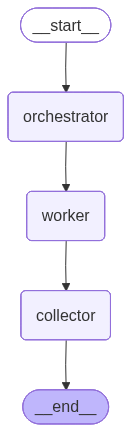

In [32]:
orch_grap_compiled = orch_graph.compile()
orch_grap_compiled

In [33]:
for chunk in orch_grap_compiled.stream(
    {
    'user_input': "What is the capital of France? What is the population of India?",
    'tasks': [],
    'results': [],
    'final_response': ""
    },
    stream_mode="updates"
):
    print(chunk)


{'orchestrator': {'user_input': 'What is the capital of France? What is the population of India?', 'tasks': ['Find the capital of France', 'Find the population of India'], 'results': [], 'final_response': ''}}
{'worker': {'user_input': 'What is the capital of France? What is the population of India?', 'tasks': ['Find the capital of France', 'Find the population of India'], 'results': ['Paris', 'About 1.43 billion people.\n\nSource: United Nations estimate for mid‑2023 (approximately 1,428,627,663). If you need a specific year or source (e.g., World Bank or India’s census), tell me.'], 'final_response': ''}}
{'collector': {'user_input': 'What is the capital of France? What is the population of India?', 'tasks': ['Find the capital of France', 'Find the population of India'], 'results': ['Paris', 'About 1.43 billion people.\n\nSource: United Nations estimate for mid‑2023 (approximately 1,428,627,663). If you need a specific year or source (e.g., World Bank or India’s census), tell me.'], 

In [ ]:
from typing import TypedDict
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

class StructOp(BaseModel):
    tasks: list[str]

class AgentState(TypedDict):
    user_input: str
    tasks: list[str]
    results: list[str]
    summary: str

def orch(state):
    input_prompt = ChatPromptTemplate.from_messages(
        [
            ('system', ''),
        ]
    )

